In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")


In [ ]:
from google.colab import files
uploaded= files.upload()

Saving health_insurance.zip to health_insurance.zip


In [ ]:
import zipfile
import io

with zipfile.ZipFile(io.BytesIO(uploaded['health_insurance.zip']), 'r') as z:
    with z.open('insurance.csv') as f:
        df = pd.read_csv(f)

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [ ]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


# data visulization

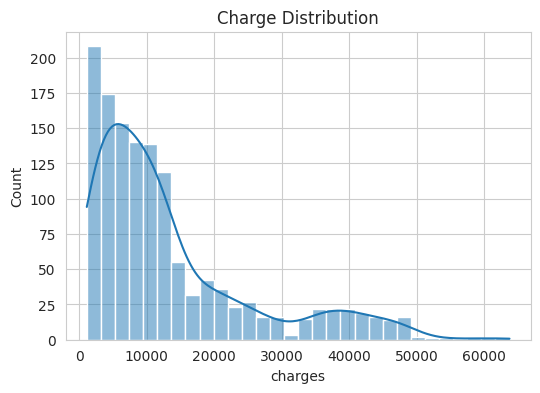

In [ ]:
# charge distribution

plt.figure(figsize=(6,4))
sns.histplot(df['charges'],kde=True)
plt.title('Charge Distribution')
plt.show()

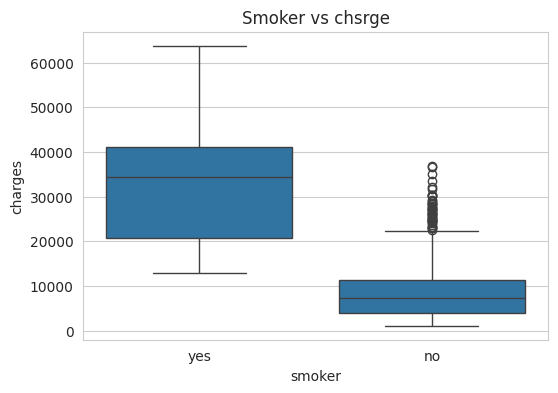

In [ ]:
# smoker vs charges

plt.figure(figsize=(6,4))
sns.boxplot(x='smoker', y='charges', data=df)
plt.title("Smoker vs chsrge")
plt.show()

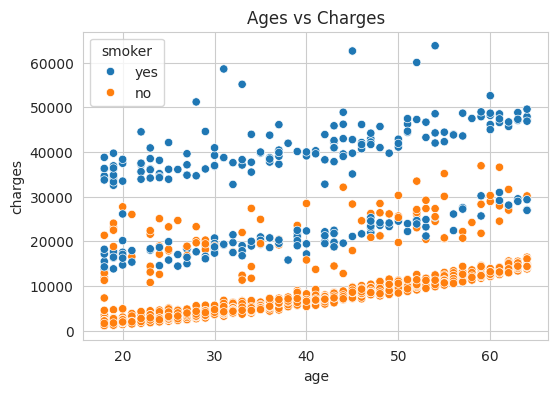

In [ ]:
# Ages vs Charges

plt.figure(figsize=(6,4))
sns.scatterplot(x='age', y='charges', hue='smoker',data=df)
plt.title("Ages vs Charges")
plt.show()

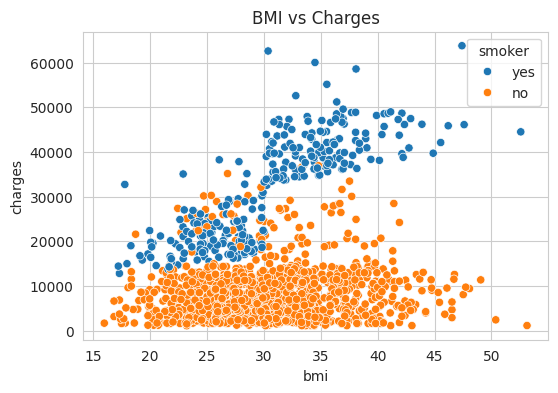

In [ ]:
# bmi vs charges

plt.figure(figsize=(6,4))
sns.scatterplot(x='bmi', y='charges', hue='smoker',data=df)
plt.title("bmi vs Charges")
plt.title("BMI vs Charges")
plt.show()

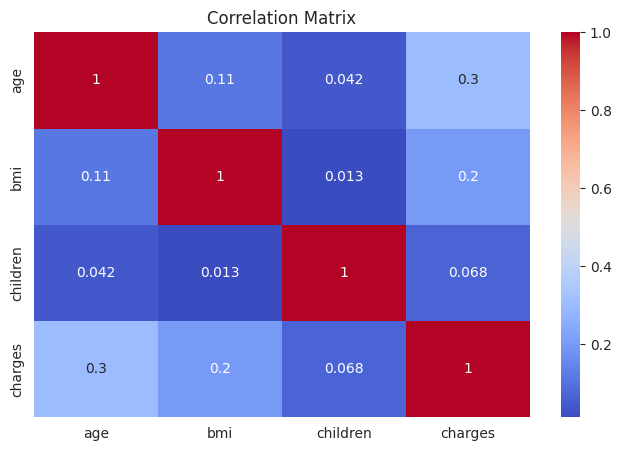

In [ ]:
# correleation heatmap

plt.figure(figsize=(8,5))
sns.heatmap(df.corr(numeric_only=True), annot=True,cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

# Feature Enginnering

In [ ]:
# fix skewness

df['charges']=np.log1p(df['charges'])


In [ ]:

df['bmi_age']=df['bmi']*df['age']

In [ ]:
# convert categorical numeric
df=pd.get_dummies(df,drop_first=True)

In [ ]:
df.head()

,age,bmi,children,charges,bmi_age,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,9.734236,530.100,False,True,False,False,True
1,18,33.770,1,7.453882,607.860,True,False,False,True,False
2,28,33.000,3,8.400763,924.000,True,False,False,True,False
3,33,22.705,0,9.998137,749.265,True,False,True,False,False
4,32,28.880,0,8.260455,924.160,True,False,True,False,False


In [ ]:
# split data

from sklearn.model_selection import train_test_split

X=df.drop('charges',axis=1)
y=df['charges']

X_train,X_test,y_train,y_test=train_test_=train_test_split(X,y,test_size=0.2,random_state=42)




# Train best module

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

model=RandomForestRegressor(
    n_estimators=300,
    random_state=42
)
model.fit(X_train,y_train)

RandomForestRegressor(n_estimators=300, random_state=42)

In [ ]:
# predication

y_pred=model.predict(X_test)

In [ ]:
# evaluation

from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

print("R2 score:", r2_score(y_test,y_pred))
print("MAE:", mean_absolute_error(y_test,y_pred))

R2 score: 0.8487547138034037
MAE: 0.19221856683886768


In [ ]:
# convert back(Real Output)

y_test_actual=np.expm1(y_test)
y_pred_actual=np.expm1(y_pred)

print("Final R2",r2_score(y_test_actual,y_pred_actual))

Final R2 0.880742051950188
